# FM Sketcher + PPO Progress Control (Maze)

This notebook returns to the original FM sketcher (time-conditioned).
PPO controls **progress along the sketch**, similar to how PPO controls rotation with the FM rotator.

The red path **is the agent** (no separate yellow dot).


In [1]:
%cd /Users/masha/Documents/visual-reasoning


/Users/masha/Documents/visual-reasoning


In [2]:
import math
import random
from collections import deque
from typing import List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import gymnasium as gym

from stable_baselines3 import PPO


Config + device helpers.

In [3]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = get_device()
print("Device:", DEVICE)

RUN_FAST = False
IMG_SIZE = 64
MAZE_CELLS = 9

TRAIN_SAMPLES = 2000 if not RUN_FAST else 400
TEST_SAMPLES = 400 if not RUN_FAST else 80
BATCH_SIZE = 32
EPOCHS = 40 if not RUN_FAST else 12
LR = 2e-4

PPO_STEPS = 100_000 if not RUN_FAST else 20_000
EVAL_EPISODES = 30 if not RUN_FAST else 8
MAX_EP_STEPS = 180

GOAL_REWARD = 10.0
PROGRESS_REWARD = 1.0
STEP_PENALTY = 0.01


Device: mps


Maze generation + utilities.

In [4]:
def generate_maze(cells_w: int, cells_h: int, rng: random.Random) -> np.ndarray:
    """Generate a perfect maze with DFS backtracking. Returns grid with 1=wall, 0=free."""
    grid = np.ones((cells_h * 2 + 1, cells_w * 2 + 1), dtype=np.uint8)
    visited = np.zeros((cells_h, cells_w), dtype=bool)

    stack = [(0, 0)]
    visited[0, 0] = True
    grid[1, 1] = 0

    while stack:
        x, y = stack[-1]
        neighbors = []
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < cells_w and 0 <= ny < cells_h and not visited[ny, nx]:
                neighbors.append((nx, ny, dx, dy))
        if neighbors:
            nx, ny, dx, dy = rng.choice(neighbors)
            grid[y * 2 + 1 + dy, x * 2 + 1 + dx] = 0
            grid[ny * 2 + 1, nx * 2 + 1] = 0
            visited[ny, nx] = True
            stack.append((nx, ny))
        else:
            stack.pop()

    return grid


def bfs_shortest_path(grid: np.ndarray, start: Tuple[int, int], goal: Tuple[int, int]) -> List[Tuple[int, int]]:
    h, w = grid.shape
    q = deque([start])
    prev = {start: None}

    while q:
        y, x = q.popleft()
        if (y, x) == goal:
            break
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and grid[ny, nx] == 0:
                if (ny, nx) not in prev:
                    prev[(ny, nx)] = (y, x)
                    q.append((ny, nx))

    if goal not in prev:
        return []

    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return path


def path_to_segments(path: List[Tuple[int, int]]) -> List[List[Tuple[int, int]]]:
    if not path:
        return []
    if len(path) == 1:
        return [[path[0]]]
    segments = []
    curr = [path[0]]
    curr_dir = (path[1][0] - path[0][0], path[1][1] - path[0][1])
    for i in range(1, len(path)):
        step = (path[i][0] - path[i - 1][0], path[i][1] - path[i - 1][1])
        if step != curr_dir:
            segments.append(curr)
            curr = [path[i - 1], path[i]]
            curr_dir = step
        else:
            curr.append(path[i])
    segments.append(curr)
    return segments


def segment_frames_from_path(path: List[Tuple[int, int]]) -> List[List[Tuple[int, int]]]:
    segments = path_to_segments(path)
    frames: List[List[Tuple[int, int]]] = [[]]
    current: List[Tuple[int, int]] = []
    for seg in segments:
        if current and seg and current[-1] == seg[0]:
            current.extend(seg[1:])
        else:
            current.extend(seg)
        frames.append(list(current))
    return frames


def one_hot_point(shape: Tuple[int, int], pos: Tuple[int, int]) -> np.ndarray:
    m = np.zeros(shape, dtype=np.float32)
    m[pos[0], pos[1]] = 1.0
    return m


def nodes_to_trace(shape: Tuple[int, int], nodes: List[Tuple[int, int]]) -> np.ndarray:
    trace = np.zeros(shape, dtype=np.float32)
    for y, x in nodes:
        trace[y, x] = 1.0
    return trace


def resize_nn(t: torch.Tensor, size: int) -> torch.Tensor:
    if t.dim() == 2:
        t = t.unsqueeze(0).unsqueeze(0)
    elif t.dim() == 3:
        t = t.unsqueeze(0)
    out = F.interpolate(t, size=(size, size), mode="nearest")
    return out.squeeze(0)


def build_cond(grid: np.ndarray, start: Tuple[int, int], goal: Tuple[int, int], img_size: int) -> torch.Tensor:
    walls = grid.astype(np.float32)
    start_ch = one_hot_point(grid.shape, start)
    goal_ch = one_hot_point(grid.shape, goal)
    cond = np.stack([walls, start_ch, goal_ch], axis=0)
    cond_t = torch.tensor(cond).float()
    return resize_nn(cond_t, img_size)


Dataset: time-conditioned sketch steps from segment frames.

In [5]:
class MazeTraceDataset(Dataset):
    def __init__(self, n_samples: int, maze_cells: int, img_size: int, seed: int = 0):
        self.n = n_samples
        self.maze_cells = maze_cells
        self.img_size = img_size
        self.rng = random.Random(seed)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        grid = generate_maze(self.maze_cells, self.maze_cells, self.rng)
        start = (1, 1)
        goal = (grid.shape[0] - 2, grid.shape[1] - 2)
        path = bfs_shortest_path(grid, start, goal)
        frames = segment_frames_from_path(path)
        if len(frames) < 2:
            return self.__getitem__(idx + 1)

        k = self.rng.randint(0, len(frames) - 2)
        trace_t = nodes_to_trace(grid.shape, frames[k])
        trace_next = nodes_to_trace(grid.shape, frames[k + 1])
        delta = trace_next - trace_t
        t = k / max(1, len(frames) - 1)

        cond = build_cond(grid, start, goal, self.img_size)
        trace_t = resize_nn(torch.tensor(trace_t).float(), self.img_size)
        delta = resize_nn(torch.tensor(delta).float(), self.img_size)

        return cond, trace_t, torch.tensor([t], dtype=torch.float32), delta


train_loader = DataLoader(MazeTraceDataset(TRAIN_SAMPLES, MAZE_CELLS, IMG_SIZE, seed=0),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(MazeTraceDataset(TEST_SAMPLES, MAZE_CELLS, IMG_SIZE, seed=123),
                         batch_size=BATCH_SIZE, shuffle=False)


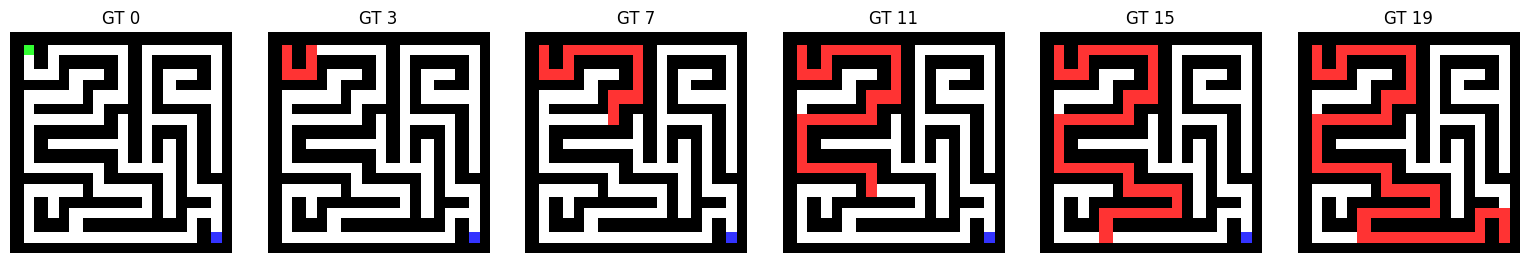

In [6]:
# --- Dataset visualization (pre-training) ---
# Show a few ground-truth frames from the segment-by-segment path.

rng = random.Random(7)
grid = generate_maze(MAZE_CELLS, MAZE_CELLS, rng)
start = (1, 1)
goal = (grid.shape[0] - 2, grid.shape[1] - 2)
path = bfs_shortest_path(grid, start, goal)
frames_gt = segment_frames_from_path(path)

cond_img = build_cond(grid, start, goal, IMG_SIZE).numpy()

idxs = np.linspace(0, max(0, len(frames_gt) - 1), num=min(6, len(frames_gt)), dtype=int)
fig, axes = plt.subplots(1, len(idxs), figsize=(2.6 * len(idxs), 2.6))
if len(idxs) == 1:
    axes = [axes]

for ax, i in zip(axes, idxs):
    trace = nodes_to_trace(grid.shape, frames_gt[i])
    trace = resize_nn(torch.tensor(trace).float(), IMG_SIZE).numpy()[0]

    walls = cond_img[0]
    start_ch = cond_img[1]
    goal_ch = cond_img[2]
    img = np.ones((walls.shape[0], walls.shape[1], 3), dtype=np.float32)
    img[walls > 0.5] = 0.0
    img[start_ch > 0.5] = np.array([0.2, 1.0, 0.2])
    img[goal_ch > 0.5] = np.array([0.2, 0.2, 1.0])
    img[trace > 0.5] = np.array([1.0, 0.2, 0.2])

    ax.imshow(img)
    ax.set_title(f"GT {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()


FM sketcher (time-conditioned).

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class MazeSketcher(nn.Module):
    def __init__(self, cond_ch: int = 3, flow_dim: int = 32):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4)
        )
        self.cond_encoder = nn.Sequential(
            nn.Conv2d(cond_ch, flow_dim, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(flow_dim, flow_dim * 2, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.cond_proj = nn.Linear(flow_dim * 2, flow_dim * 4)

        self.inc = DoubleConv(1 + cond_ch, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim * 2, flow_dim * 4))

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv1 = DoubleConv(flow_dim * 6, flow_dim * 2)
        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv2 = DoubleConv(flow_dim * 3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, 1, kernel_size=1)

    def forward(self, trace_t: torch.Tensor, cond: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        if t.dim() == 1:
            t = t.unsqueeze(1)
        t_emb = self.time_mlp(t)
        c = self.cond_encoder(cond).squeeze(-1).squeeze(-1)
        c_emb = self.cond_proj(c)
        global_cond = (t_emb + c_emb).unsqueeze(-1).unsqueeze(-1)

        x = torch.cat([trace_t, cond], dim=1)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)


Train FM sketcher.

Epoch 01 | loss 0.02088
Epoch 05 | loss 0.00317
Epoch 10 | loss 0.00143
Epoch 15 | loss 0.00102
Epoch 20 | loss 0.00080
Epoch 25 | loss 0.00070
Epoch 30 | loss 0.00064
Epoch 35 | loss 0.00052
Epoch 40 | loss 0.00046


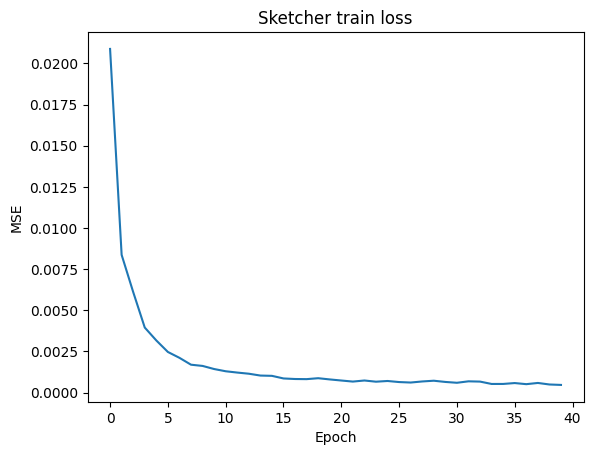

In [8]:
set_seed(0)

sketcher = MazeSketcher(cond_ch=3, flow_dim=32).to(DEVICE)
optimizer = torch.optim.AdamW(sketcher.parameters(), lr=LR)

train_losses = []
for epoch in range(EPOCHS):
    sketcher.train()
    epoch_loss = 0.0
    for cond, trace_t, t, delta in train_loader:
        cond = cond.to(DEVICE)
        trace_t = trace_t.to(DEVICE)
        t = t.to(DEVICE)
        delta = delta.to(DEVICE)

        pred = sketcher(trace_t, cond, t)
        loss = F.mse_loss(pred, delta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg = epoch_loss / max(1, len(train_loader))
    train_losses.append(avg)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:02d} | loss {avg:.5f}")

plt.plot(train_losses)
plt.title("Sketcher train loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()


Visualize the FM sketcher drawing the red path.

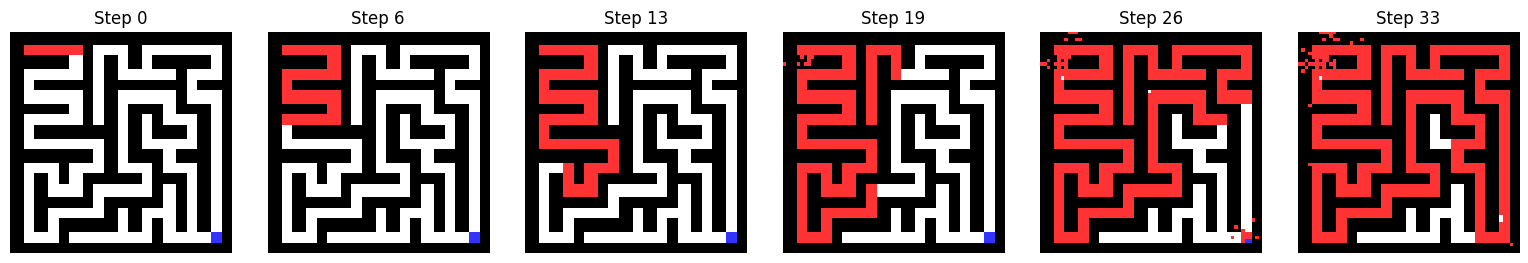

In [9]:
@torch.no_grad()
def rollout_sketch(model: nn.Module, cond: torch.Tensor, steps: int, device: torch.device):
    model.eval()
    b, _, h, w = cond.shape
    trace = torch.zeros((b, 1, h, w), device=device)
    frames = []
    for i in range(steps):
        t = torch.tensor([[i / max(1, steps - 1)]], device=device)
        delta = model(trace, cond, t)
        trace = (trace + delta).clamp(0.0, 1.0)
        frames.append(trace.detach().cpu())
    return frames


def compose_rgb(cond: np.ndarray, trace: Optional[np.ndarray] = None) -> np.ndarray:
    walls = cond[0]
    start = cond[1]
    goal = cond[2]
    h, w = walls.shape
    img = np.ones((h, w, 3), dtype=np.float32)
    img[walls > 0.5] = 0.0
    img[start > 0.5] = np.array([0.2, 1.0, 0.2])
    img[goal > 0.5] = np.array([0.2, 0.2, 1.0])
    if trace is not None:
        img[trace > 0.5] = np.array([1.0, 0.2, 0.2])
    return img


# sample maze + path
rng = random.Random(42)
grid = generate_maze(MAZE_CELLS, MAZE_CELLS, rng)
start = (1, 1)
goal = (grid.shape[0] - 2, grid.shape[1] - 2)
path = bfs_shortest_path(grid, start, goal)
frames_gt = segment_frames_from_path(path)

cond_img = build_cond(grid, start, goal, IMG_SIZE)
cond_t = cond_img.unsqueeze(0).to(DEVICE)

frames = rollout_sketch(sketcher, cond_t, steps=len(frames_gt), device=DEVICE)

idxs = np.linspace(0, len(frames) - 1, num=min(6, len(frames)), dtype=int)
fig, axes = plt.subplots(1, len(idxs), figsize=(2.6 * len(idxs), 2.6))
if len(idxs) == 1:
    axes = [axes]
for ax, i in zip(axes, idxs):
    trace = frames[i][0, 0].numpy()
    img = compose_rgb(cond_img.numpy(), trace=trace)
    ax.imshow(img)
    ax.set_title(f"Step {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()


Gymnasium env: PPO controls sketch progress (like FM rotator).

In [10]:
class MazeEnvFMProgress(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        sketcher: nn.Module,
        maze_cells: int = 9,
        img_size: int = 64,
        max_steps: int = 180,
        device: Optional[torch.device] = None,
        seed: int = 0,
    ):
        super().__init__()
        self.sketcher = sketcher
        self.maze_cells = maze_cells
        self.img_size = img_size
        self.max_steps = max_steps
        self.device = device or get_device()
        self.rng = random.Random(seed)

        # channels: walls, start, goal, trace (red path == agent)
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1.0, shape=(4, img_size, img_size), dtype=np.float32
        )
        # actions: advance by 1, 2, 4, or hold
        self.action_space = gym.spaces.Discrete(4)
        self.action_steps = {0: 1, 1: 2, 2: 4, 3: 0}

        self.grid = None
        self.start = None
        self.goal = None
        self.frames_len = None
        self.progress = 0
        self.trace = None
        self.cond = None
        self.goal_mask = None
        self.step_count = 0

    def _obs(self) -> np.ndarray:
        trace_np = self.trace[0].detach().cpu().numpy()  # (1, H, W)
        cond_np = self.cond[0].detach().cpu().numpy()  # (3, H, W)
        obs = np.concatenate([cond_np, trace_np], axis=0)
        return obs.astype(np.float32)

    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = random.Random(seed)

        grid = generate_maze(self.maze_cells, self.maze_cells, self.rng)
        start = (1, 1)
        goal = (grid.shape[0] - 2, grid.shape[1] - 2)
        path = bfs_shortest_path(grid, start, goal)
        frames = segment_frames_from_path(path)

        self.grid = grid
        self.start = start
        self.goal = goal
        self.frames_len = max(2, len(frames))
        self.progress = 0
        self.step_count = 0

        cond = build_cond(grid, start, goal, self.img_size)
        self.cond = cond.unsqueeze(0).to(self.device)
        goal_ch = one_hot_point(grid.shape, goal)
        self.goal_mask = resize_nn(torch.tensor(goal_ch).float(), self.img_size).to(self.device)
        self.trace = torch.zeros((1, 1, self.img_size, self.img_size), device=self.device)

        return self._obs(), {}

    def step(self, action: int):
        n = self.action_steps.get(int(action), 1)
        prev_progress = self.progress
        # advance FM sketch n steps
        for _ in range(n):
            if self.progress >= self.frames_len - 1:
                break
            t = torch.tensor([[self.progress / max(1, self.frames_len - 1)]], device=self.device)
            with torch.no_grad():
                delta = self.sketcher(self.trace, self.cond, t)
            self.trace = (self.trace + delta).clamp(0.0, 1.0)
            self.progress += 1

        progress_delta = self.progress - prev_progress
        reward = -STEP_PENALTY + PROGRESS_REWARD * (progress_delta / max(1, self.frames_len - 1))

        terminated = False
        # terminate if we've advanced through the full sketch
        if self.progress >= self.frames_len - 1:
            reward += GOAL_REWARD
            terminated = True

        # bonus if the red trace actually reaches the goal
        goal_on_trace = (self.trace[0, 0] * self.goal_mask[0]).sum().item() > 0.5
        if goal_on_trace and not terminated:
            reward += GOAL_REWARD * 0.5
            terminated = True

        self.step_count += 1
        truncated = self.step_count >= self.max_steps

        return self._obs(), float(reward), terminated, truncated, {}


Train PPO to control sketch progress.

In [11]:
set_seed(0)

env = MazeEnvFMProgress(
    sketcher=sketcher,
    maze_cells=MAZE_CELLS,
    img_size=IMG_SIZE,
    max_steps=MAX_EP_STEPS,
    device=DEVICE,
    seed=0,
)

model = PPO(
    "CnnPolicy",
    env,
    verbose=1,
    device="mps" if DEVICE.type == "mps" else DEVICE,
    learning_rate=2e-4,
    policy_kwargs={"normalize_images": False},
)

from stable_baselines3.common.logger import configure
log_dir = "logs/ppo_maze_fm_progress"
logger = configure(log_dir, ["stdout", "csv"])
model.set_logger(logger)

model.learn(total_timesteps=PPO_STEPS)

Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to logs/ppo_maze_fm_progress
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 9.89     |
|    ep_rew_mean     | 6.42     |
| time/              |          |
|    fps             | 165      |
|    iterations      | 1        |
|    time_elapsed    | 12       |
|    total_timesteps | 2048     |
---------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 9.27      |
|    ep_rew_mean          | 6.31      |
| time/                   |           |
|    fps                  | 126       |
|    iterations           | 2         |
|    time_elapsed         | 32        |
|    total_timesteps      | 4096      |
| train/                  |           |
|    approx_kl            | 0.0189485 |
|    clip_fraction        | 0.291     |
|    clip_range           | 0.2       |
|    entr

Evaluate success rate.

In [12]:
eval_env = MazeEnvFMProgress(
    sketcher=sketcher,
    maze_cells=MAZE_CELLS,
    img_size=IMG_SIZE,
    max_steps=MAX_EP_STEPS,
    device=DEVICE,
    seed=123,
)

success = 0
rewards = []
for _ in range(EVAL_EPISODES):
    obs, _ = eval_env.reset()
    terminated = False
    truncated = False
    ep_reward = 0.0

    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = eval_env.step(int(action))
        ep_reward += reward

    rewards.append(ep_reward)
    if terminated:
        success += 1

print(f"Mean episode reward: {np.mean(rewards):.2f}")
print(f"Success rate: {success / EVAL_EPISODES:.2%}")


Mean episode reward: 4.37
Success rate: 73.33%


Plot PPO losses (same style as pipeline_tetris).

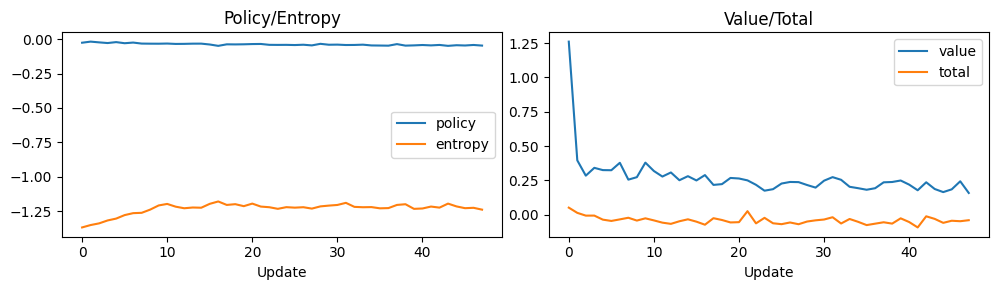

In [13]:
import csv
import os

log_path = os.path.join(log_dir, "progress.csv")
if not os.path.exists(log_path):
    print(f"No progress.csv found at {log_path}. Did training run?")
else:
    with open(log_path, "r", newline="") as f:
        rows = list(csv.DictReader(f))

    def get_series(key: str):
        vals = []
        for r in rows:
            v = r.get(key, "")
            if v != "" and v is not None:
                vals.append(float(v))
        return vals

    policy_loss = get_series("train/policy_gradient_loss")
    value_loss = get_series("train/value_loss")
    entropy_loss = get_series("train/entropy_loss")
    total_loss = get_series("train/loss")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    if policy_loss:
        axes[0].plot(policy_loss, label="policy")
    if entropy_loss:
        axes[0].plot(entropy_loss, label="entropy")
    axes[0].set_title("Policy/Entropy")
    axes[0].set_xlabel("Update")
    axes[0].legend()

    if value_loss:
        axes[1].plot(value_loss, label="value")
    if total_loss:
        axes[1].plot(total_loss, label="total")
    axes[1].set_title("Value/Total")
    axes[1].set_xlabel("Update")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


Rollout GIFs (4 samples) side-by-side.


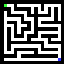
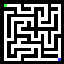
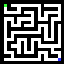
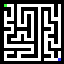

['gifs/maze_ppo_fm_progress_1.gif', 'gifs/maze_ppo_fm_progress_2.gif', 'gifs/maze_ppo_fm_progress_3.gif', 'gifs/maze_ppo_fm_progress_4.gif']


In [14]:
import imageio.v2 as imageio
import os
import base64
from IPython.display import HTML, display


def render_env_frame(env: MazeEnvFMProgress) -> np.ndarray:
    cond = env.cond[0].detach().cpu().numpy()
    trace = env.trace[0].detach().cpu().numpy()[0]
    walls = cond[0]
    start_ch = cond[1]
    goal_ch = cond[2]
    img = np.ones((walls.shape[0], walls.shape[1], 3), dtype=np.float32)
    img[walls > 0.5] = 0.0
    img[start_ch > 0.5] = np.array([0.2, 1.0, 0.2])
    img[goal_ch > 0.5] = np.array([0.2, 0.2, 1.0])
    img[trace > 0.5] = np.array([1.0, 0.2, 0.2])
    return (img * 255).astype(np.uint8)


def rollout_and_save_gif(env: MazeEnvFMProgress, model: PPO, out_path: str, max_steps: int = 120, fps: int = 6, seed: int | None = None):
    if seed is not None:
        set_seed(seed)
    obs, _ = env.reset()
    frames = []
    for _ in range(max_steps):
        frames.append(render_env_frame(env))
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(int(action))
        if terminated or truncated:
            frames.append(render_env_frame(env))
            break

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    imageio.mimsave(out_path, frames, fps=fps)
    return out_path


def gif_to_base64(path: str) -> str:
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("ascii")


gif_env = MazeEnvFMProgress(
    sketcher=sketcher,
    maze_cells=MAZE_CELLS,
    img_size=IMG_SIZE,
    max_steps=MAX_EP_STEPS,
    device=DEVICE,
    seed=999,
)

num_gifs = 4
gif_paths = []
base_seed = 12345
for i in range(num_gifs):
    out_path = f"gifs/maze_ppo_fm_progress_{i+1}.gif"
    gif_paths.append(rollout_and_save_gif(gif_env, model, out_path=out_path, seed=base_seed + i))

html = "<div style='display:flex; gap:12px; flex-wrap:wrap; align-items:flex-start;'>" + "".join(
    [f"<div style='text-align:center'><img src='data:image/gif;base64,{gif_to_base64(p)}' style='width:160px; image-rendering:pixelated;'/><div style='font-size:12px'>{os.path.basename(p)}</div></div>" for p in gif_paths]
) + "</div>"

display(HTML(html))

print(gif_paths)
